In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from scipy.stats import skew
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [18]:
df.shape

(768, 9)

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


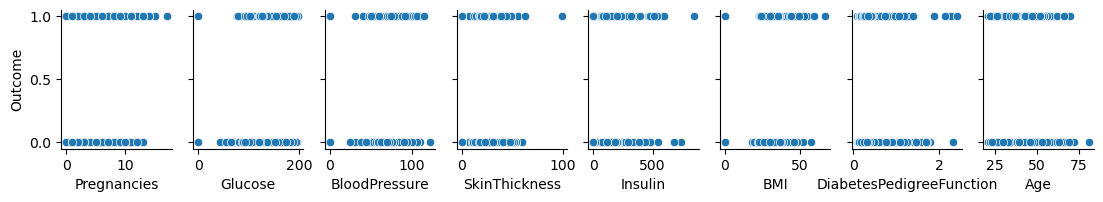

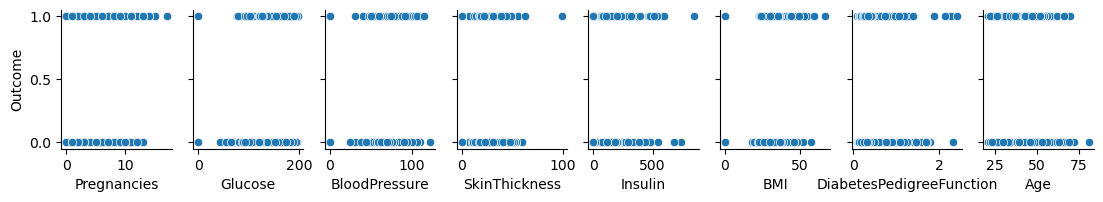

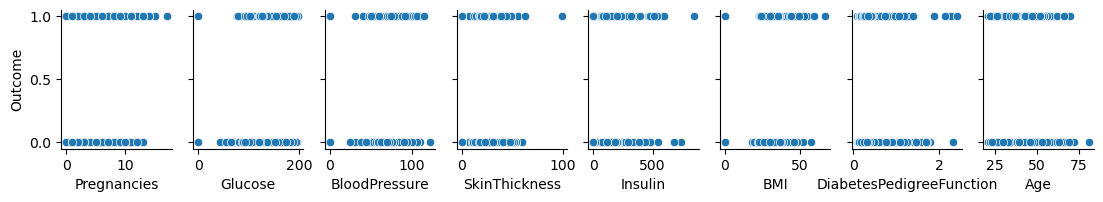

In [21]:
sns.pairplot(df, x_vars=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"],y_vars='Outcome',kind="scatter", height=2,aspect=0.7)
plt.show()

In [8]:
x=df[["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]]
y=df["Outcome"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [11]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [12]:
xtrainpred=model.predict(x_train)
from sklearn.metrics import accuracy_score
TrainDataAccuracy=accuracy_score(xtrainpred,y_train)
print("The accuracy score is",TrainDataAccuracy)

The accuracy score is 1.0


In [32]:
xtestpred=model.predict(x_test)
TestDataAccuracy=accuracy_score(xtestpred,y_test)
print("The accuracy score is",TestDataAccuracy)

The accuracy score is 0.7532467532467533


In [16]:
param_grid= {
    'max_features':['sqrt','log2'],
    'max_depth':[4,5,6,7,8],
    'criterion':['gini','entropy'],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[2,5,10],
    'bootstrap':[True,False]
}

In [17]:
from sklearn.model_selection import GridSearchCV
model_GS=GridSearchCV(estimator=model, param_grid=param_grid, cv=5) 
model_GS.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [2, 5, 10]})

In [18]:
model_GS.best_params_

{'bootstrap': False,
 'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 5,
 'min_samples_split': 2}

In [19]:
print(model_GS.best_score_)

0.7915500466480074


In [23]:
max_features = ['sqrt','log2']
max_depth = [10,20,30,40]
criterion = ['gini','entropy']
min_samples_split = [2,5,10]
min_samples_leaf = [1,2,4]
bootstrap = [True,False]

In [24]:
random_grid= {
    'max_features':max_features,
    'max_depth':max_depth,
    'criterion':criterion,
    'min_samples_split':min_samples_split,
    'min_samples_leaf':min_samples_leaf,
    'bootstrap':bootstrap
}

In [27]:
from sklearn.model_selection import RandomizedSearchCV
model_rs=RandomizedSearchCV(estimator=model, param_distributions=random_grid, verbose=2, cv=10, n_iter=10, n_jobs = 4)

In [28]:
model_rs.fit(x_train,y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=4,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   verbose=2)

In [29]:
model_rs.best_params_

{'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 10,
 'criterion': 'gini',
 'bootstrap': True}

In [31]:
print(model_rs.best_score_)

0.7833685880486516
